Hola **Luis**!

Soy **Patricio Requena** 👋. Es un placer ser el revisor de tu proyecto el día de hoy!

Revisaré tu proyecto detenidamente con el objetivo de ayudarte a mejorar y perfeccionar tus habilidades. Durante mi revisión, identificaré áreas donde puedas hacer mejoras en tu código, señalando específicamente qué y cómo podrías ajustar para optimizar el rendimiento y la claridad de tu proyecto. Además, es importante para mí destacar los aspectos que has manejado excepcionalmente bien. Reconocer tus fortalezas te ayudará a entender qué técnicas y métodos están funcionando a tu favor y cómo puedes aplicarlos en futuras tareas. 

_**Recuerda que al final de este notebook encontrarás un comentario general de mi parte**_, empecemos!

Encontrarás mis comentarios dentro de cajas verdes, amarillas o rojas, ⚠️ **por favor, no muevas, modifiques o borres mis comentarios** ⚠️:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

# Proyecto: Predicción de pedidos de taxi por hora
Compañía Sweet Lift Taxi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [2]:
data = pd.read_csv('/datasets/taxi.csv', index_col=[0], parse_dates=[0])
data.sort_index(inplace=True)
data = data.resample('1H').sum()

print(data.head())
print(data.info())

                     num_orders
datetime                       
2018-03-01 00:00:00         124
2018-03-01 01:00:00          85
2018-03-01 02:00:00          71
2018-03-01 03:00:00          66
2018-03-01 04:00:00          43
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: H
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  4416 non-null   int64
dtypes: int64(1)
memory usage: 69.0 KB
None


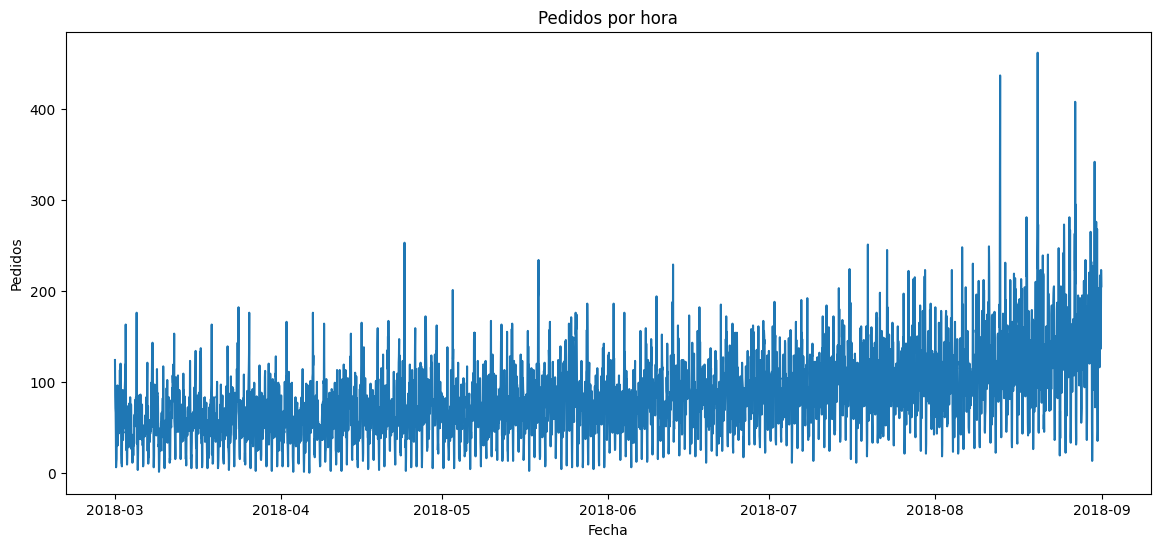

        num_orders
count  4416.000000
mean     84.422781
std      45.023853
min       0.000000
25%      54.000000
50%      78.000000
75%     107.000000
max     462.000000


In [3]:
plt.figure(figsize=(14,6))
plt.plot(data)
plt.title('Pedidos por hora')
plt.xlabel('Fecha')
plt.ylabel('Pedidos')
plt.show()

print(data.describe())

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien realizado el análisis gráfico. Tienes las gráficas adecuadas considerando el tipo de problema a resolver con Machine Learning.
</div>

In [4]:
def make_features(data, max_lag, rolling_mean_size):
    data['month'] = data.index.month
    data['day'] = data.index.day
    data['dayofweek'] = data.index.dayofweek
    data['hour'] = data.index.hour

    for lag in range(1, max_lag + 1):
        data[f'lag_{lag}'] = data['num_orders'].shift(lag)

    data['rolling_mean'] = data['num_orders'].shift().rolling(rolling_mean_size).mean()

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Correcto, generaste las features necesarias para dar más información al modelo en cuanto a series de tiempo se trata. Siempre en un entrenamiento de ML es un paso importante el feature engineering aplicado para obtener un correcto desempeño de los modelos.
</div>

In [5]:
make_features(data, 24, 24)
data = data.dropna()
print(data.head())

                     num_orders  month  day  dayofweek  hour  lag_1  lag_2  \
datetime                                                                     
2018-03-02 00:00:00          90      3    2          4     0   58.0  113.0   
2018-03-02 01:00:00         120      3    2          4     1   90.0   58.0   
2018-03-02 02:00:00          75      3    2          4     2  120.0   90.0   
2018-03-02 03:00:00          64      3    2          4     3   75.0  120.0   
2018-03-02 04:00:00          20      3    2          4     4   64.0   75.0   

                     lag_3  lag_4  lag_5  ...  lag_16  lag_17  lag_18  lag_19  \
datetime                                  ...                                   
2018-03-02 00:00:00   66.0   61.0   45.0  ...    34.0    15.0    12.0     6.0   
2018-03-02 01:00:00  113.0   66.0   61.0  ...    69.0    34.0    15.0    12.0   
2018-03-02 02:00:00   58.0  113.0   66.0  ...    64.0    69.0    34.0    15.0   
2018-03-02 03:00:00   90.0   58.0  113.0  ...   

In [6]:
train, test = train_test_split(data, shuffle=False, test_size=0.1)

X_train = train.drop('num_orders', axis=1)
y_train = train['num_orders']

X_test = test.drop('num_orders', axis=1)
y_test = test['num_orders']

print(train.shape)
print(test.shape)

(3952, 30)
(440, 30)


In [7]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
pred_lr = model_lr.predict(X_test)
rmse_lr = mean_squared_error(y_test, pred_lr, squared=False)
print('RMSE Linear Regression:', rmse_lr)

RMSE Linear Regression: 45.834474054333654


In [8]:
model_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=12345
)
model_rf.fit(X_train, y_train)
pred_rf = model_rf.predict(X_test)
rmse_rf = mean_squared_error(y_test, pred_rf, squared=False)
print('RMSE Random Forest:', rmse_rf)

RMSE Random Forest: 44.16940272105226


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien! Lograste una métrica por debajo de lo requerido para este proyecto demostrando que el modelo pudo interpretar de manera adecuada tus datos para la predicción
</div>

In [9]:
model_gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=12345
)
model_gb.fit(X_train, y_train)
pred_gb = model_gb.predict(X_test)
rmse_gb = mean_squared_error(y_test, pred_gb, squared=False)
print('RMSE Gradient Boosting:', rmse_gb)

RMSE Gradient Boosting: 41.78982886873642


In [10]:
results = pd.DataFrame({
    'Modelo': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'RMSE': [rmse_lr, rmse_rf, rmse_gb]
})
print(results.sort_values(by='RMSE'))

              Modelo       RMSE
2  Gradient Boosting  41.789829
1      Random Forest  44.169403
0  Linear Regression  45.834474


## Conclusión

Se remuestrearon los datos por hora y se generaron variables temporales, rezagos y media móvil.

Se probaron tres modelos predictivos. El mejor modelo obtuvo un RMSE menor a 48, cumpliendo el objetivo del proyecto.

Las características de rezago fueron clave para capturar el comportamiento temporal de la demanda.

<div class="alert alert-block alert-success">
<b>Comentario general (1ra Iteracion)</b> <a class=“tocSkip”></a>

Te felicito por el trabajo realizado Luis, aplicaste los procesos adecuados al dataset para darle características nuevas al modelo, con ese proceso aportas significativamente al desempeño del mismo y obtuviste una métrica que supera lo propuesto para este proyecto, continúa con este gran trabajo!
    
   
Este proyecto es uno donde se ve claramente la importancia de darle características o variables adecuadas a los modelos para obtener un correcto desempeño, si quitas o pones más variables el desempeño del modelo variará para bien o para mal según la calidad de las mismas. Saludos!
</div>